In [307]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import SelectKBest, f_regression

from sklearn.linear_model import Ridge

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
# imports for the libraries that i will use

In [308]:
df = pd.read_csv("final_internship_data.csv")
df.head()
# for loading the data and show me the first five rows

,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,KHVrEVlD,Kimberly Adams,Amy Butler,Very Good,windy,Congested Traffic,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21,-1.288826,...,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897
1,lPxIuEri,Justin Tapia,Hannah Zimmerman,Excellent,cloudy,Flow Traffic,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16,-1.291824,...,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217
2,gsVN8JLS,Elizabeth Lopez,Amanda Jackson,Bad,stormy,Congested Traffic,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00,-1.291242,...,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961
3,9I7kWFgd,Steven Wilson,Amy Horn,Very Good,stormy,Flow Traffic,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42,-1.291319,...,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905
4,8QN5ZaGN,Alexander Andrews,Cassandra Larson,Bad,stormy,Congested Traffic,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00,-1.290987,...,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703


In [309]:
print("Dataset Shape:", df.shape)
# for know how many rows and coiumns in the csv file

Dataset Shape: (500000, 26)


In [310]:
df.info()
# show me the types that data contains

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   User ID            500000 non-null  object 
 1   User Name          500000 non-null  object 
 2   Driver Name        500000 non-null  object 
 3   Car Condition      500000 non-null  object 
 4   Weather            500000 non-null  object 
 5   Traffic Condition  500000 non-null  object 
 6   key                500000 non-null  object 
 7   fare_amount        500000 non-null  float64
 8   pickup_datetime    500000 non-null  object 
 9   pickup_longitude   500000 non-null  float64
 10  pickup_latitude    500000 non-null  float64
 11  dropoff_longitude  499995 non-null  float64
 12  dropoff_latitude   499995 non-null  float64
 13  passenger_count    500000 non-null  int64  
 14  hour               500000 non-null  int64  
 15  day                500000 non-null  int64  
 16  mo

In [311]:
missing = df.isnull().sum()
print(missing)
# sho me how many missing elements in each column

User ID              0
User Name            0
Driver Name          0
Car Condition        0
Weather              0
Traffic Condition    0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    5
dropoff_latitude     5
passenger_count      0
hour                 0
day                  0
month                0
weekday              0
year                 0
jfk_dist             5
ewr_dist             5
lga_dist             5
sol_dist             5
nyc_dist             5
distance             5
bearing              5
dtype: int64


In [312]:
columns_to_drop = [
    "User ID",
    "User Name",
    "Driver Name"
]

df.drop(columns=columns_to_drop, inplace=True)
#drop useless columns

In [313]:
df.head()

,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,Very Good,windy,Congested Traffic,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21,-1.288826,0.710721,-1.288779,0.710563,...,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897
1,Excellent,cloudy,Flow Traffic,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16,-1.291824,0.710546,-1.291182,0.711780,...,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217
2,Bad,stormy,Congested Traffic,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00,-1.291242,0.711418,-1.291391,0.711231,...,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961
3,Very Good,stormy,Flow Traffic,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42,-1.291319,0.710927,-1.291396,0.711363,...,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905
4,Bad,stormy,Congested Traffic,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00,-1.290987,0.711536,-1.290787,0.711811,...,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703


In [314]:
df.drop_duplicates(subset="key", inplace=True)
print(df.duplicated().sum())
# drop the duplicates using key because it is use only for deduplication

0


In [315]:
df.drop(columns=["key"], inplace=True)

In [316]:
df.head()

,Car Condition,Weather,Traffic Condition,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,Very Good,windy,Congested Traffic,4.5,2009-06-15 17:26:21,-1.288826,0.710721,-1.288779,0.710563,1,...,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897
1,Excellent,cloudy,Flow Traffic,16.9,2010-01-05 16:52:16,-1.291824,0.710546,-1.291182,0.711780,1,...,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217
2,Bad,stormy,Congested Traffic,5.7,2011-08-18 00:35:00,-1.291242,0.711418,-1.291391,0.711231,2,...,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961
3,Very Good,stormy,Flow Traffic,7.7,2012-04-21 04:30:42,-1.291319,0.710927,-1.291396,0.711363,1,...,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905
4,Bad,stormy,Congested Traffic,5.3,2010-03-09 07:51:00,-1.290987,0.711536,-1.290787,0.711811,1,...,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703


In [317]:
print(df.duplicated().sum())

0


In [318]:
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
count,500000.000000,500000.000000,500000.000000,499995.000000,499995.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000
mean,11.358361,-1.265712,0.696740,-1.265755,0.696675,1.683428,13.510834,15.684206,6.268650,3.042008,2011.739132,385.279367,380.503657,363.843772,363.674038,355.991423,19.468775,0.297145
std,9.916617,0.206941,0.140909,0.205903,0.128997,1.307395,6.511571,8.681066,3.437815,1.949240,1.860889,2419.087483,2428.804740,2425.075903,2428.348683,2428.730839,367.299601,1.804548
min,-44.900000,-52.119764,-54.389440,-59.049665,-44.676047,0.000000,0.000000,1.000000,1.000000,0.000000,2009.000000,1.017646,1.460945,0.382119,0.532545,0.080500,0.000000,-3.141593
25%,6.000000,-1.291405,0.710958,-1.291393,0.710943,1.000000,9.000000,8.000000,3.000000,1.000000,2010.000000,41.341514,32.173712,17.100762,14.886989,7.147384,1.214550,-0.854721
50%,8.500000,-1.291226,0.711268,-1.291197,0.711277,1.000000,14.000000,16.000000,6.000000,3.000000,2012.000000,42.523163,34.787507,19.591554,18.347580,10.458151,2.116970,-0.050442
75%,12.500000,-1.290970,0.711520,-1.290908,0.711538,2.000000,19.000000,23.000000,9.000000,5.000000,2013.000000,43.785649,38.304502,22.214815,22.417812,14.448699,3.890070,2.206769
max,500.000000,37.360538,29.724576,0.712985,7.061893,6.000000,23.000000,31.000000,12.000000,6.000000,2015.000000,30133.067880,30167.595967,30167.285794,30159.407296,30162.285356,12399.956433,3.141593


In [319]:
df.dropna(inplace=True)
#I choose to drop the missing values because it is just a 5 values in the columns

In [320]:
categorical_columns = df.select_dtypes(include=['object']).columns
print(categorical_columns)
# this is for show which columns contain objects(string)

Index(['Car Condition', 'Weather', 'Traffic Condition', 'pickup_datetime'], dtype='object')


In [321]:
for col in categorical_columns:
    print(f"\n{df[col].value_counts()}")
    # this is a loop that will loop arount the 4 object c olumn to show me how many values each column contains
    # to know if i will use one _hot encoding or label encoding


Car Condition
Very Good    125310
Bad          124977
Good         124967
Excellent    124741
Name: count, dtype: int64

Weather
sunny     100433
cloudy    100060
rainy      99971
stormy     99955
windy      99576
Name: count, dtype: int64

Traffic Condition
Congested Traffic    166846
Dense Traffic        166581
Flow Traffic         166568
Name: count, dtype: int64

pickup_datetime
2012-01-28 13:38:00    6
2012-01-26 21:22:00    6
2014-07-25 19:25:00    5
2010-01-11 18:54:00    5
2012-03-31 23:19:00    5
                      ..
2011-05-27 22:39:21    1
2015-04-28 22:53:03    1
2014-09-14 21:39:27    1
2014-05-09 23:42:42    1
2009-10-28 16:13:34    1
Name: count, Length: 461201, dtype: int64


In [322]:
from sklearn.preprocessing import OneHotEncoder
one_hot_encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)

# Fit and transform the 'Weather' column
encoded_weather = one_hot_encoder.fit_transform(df[['Weather']])

# Get the new feature names for the 'Weather' column
weather_feature_names = one_hot_encoder.get_feature_names_out(['Weather'])

# Create a DataFrame from the encoded 'Weather' features
encoded_weather_df = pd.DataFrame(encoded_weather, columns=weather_feature_names, index=df.index)

# Drop the original 'Weather' column from df and concatenate the new encoded DataFrame
df = pd.concat([df.drop(columns=['Weather']), encoded_weather_df], axis=1)

df.head()

,Car Condition,Traffic Condition,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,...,lga_dist,sol_dist,nyc_dist,distance,bearing,Weather_cloudy,Weather_rainy,Weather_stormy,Weather_sunny,Weather_windy
0,Very Good,Congested Traffic,4.5,2009-06-15 17:26:21,-1.288826,0.710721,-1.288779,0.710563,1,17,...,14.342611,34.543548,27.572573,1.030764,-2.918897,0.0,0.0,0.0,0.0,1.0
1,Excellent,Flow Traffic,16.9,2010-01-05 16:52:16,-1.291824,0.710546,-1.291182,0.711780,1,16,...,23.130775,15.125872,8.755732,8.450134,-0.375217,1.0,0.0,0.0,0.0,0.0
2,Bad,Congested Traffic,5.7,2011-08-18 00:35:00,-1.291242,0.711418,-1.291391,0.711231,2,0,...,19.865289,17.722624,9.847344,1.389525,2.599961,0.0,0.0,1.0,0.0,0.0
3,Very Good,Flow Traffic,7.7,2012-04-21 04:30:42,-1.291319,0.710927,-1.291396,0.711363,1,4,...,21.063132,15.738963,7.703421,2.799270,0.133905,0.0,0.0,1.0,0.0,0.0
4,Bad,Congested Traffic,5.3,2010-03-09 07:51:00,-1.290987,0.711536,-1.290787,0.711811,1,7,...,15.219339,23.732406,15.600745,1.999157,-0.502703,0.0,0.0,1.0,0.0,0.0


In [323]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder(
    categories=[
        [
            'Bad',
            'Good',
            'Very Good',
            'Excellent'
        ],
        [
            'Flow Traffic',
            'Dense Traffic',
            'Congested Traffic'
        ]
    ]
)

df[['Car Condition', 'Traffic Condition']] = ordinal_encoder.fit_transform(
    df[['Car Condition', 'Traffic Condition']]
)


In [324]:
df.head()

,Car Condition,Traffic Condition,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,...,lga_dist,sol_dist,nyc_dist,distance,bearing,Weather_cloudy,Weather_rainy,Weather_stormy,Weather_sunny,Weather_windy
0,2.0,2.0,4.5,2009-06-15 17:26:21,-1.288826,0.710721,-1.288779,0.710563,1,17,...,14.342611,34.543548,27.572573,1.030764,-2.918897,0.0,0.0,0.0,0.0,1.0
1,3.0,0.0,16.9,2010-01-05 16:52:16,-1.291824,0.710546,-1.291182,0.711780,1,16,...,23.130775,15.125872,8.755732,8.450134,-0.375217,1.0,0.0,0.0,0.0,0.0
2,0.0,2.0,5.7,2011-08-18 00:35:00,-1.291242,0.711418,-1.291391,0.711231,2,0,...,19.865289,17.722624,9.847344,1.389525,2.599961,0.0,0.0,1.0,0.0,0.0
3,2.0,0.0,7.7,2012-04-21 04:30:42,-1.291319,0.710927,-1.291396,0.711363,1,4,...,21.063132,15.738963,7.703421,2.799270,0.133905,0.0,0.0,1.0,0.0,0.0
4,0.0,2.0,5.3,2010-03-09 07:51:00,-1.290987,0.711536,-1.290787,0.711811,1,7,...,15.219339,23.732406,15.600745,1.999157,-0.502703,0.0,0.0,1.0,0.0,0.0


In [325]:
df.drop(columns=['pickup_datetime'], inplace=True)
# All ready have tables that represent (year , day , month )

In [326]:
# i did this step because the min of the fare amount is negative value
(df['fare_amount'] < 0).sum()

np.int64(21)

In [327]:
# calculate the count of the negative values
df[df['fare_amount'] < 0]['fare_amount'].value_counts()

,count
fare_amount,
-2.5,6
-3.0,4
-5.0,4
-2.9,2
-6.5,2
-44.9,1
-4.5,1
-18.1,1


In [328]:
df[df['fare_amount'] < 0].head()

,Car Condition,Traffic Condition,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,...,lga_dist,sol_dist,nyc_dist,distance,bearing,Weather_cloudy,Weather_rainy,Weather_stormy,Weather_sunny,Weather_windy
2039,1.0,2.0,-2.9,-1.287869,0.709363,-1.287855,0.709336,1,23,9,...,33.066859,44.312412,39.949645,0.184225,-2.773833,0.0,0.0,1.0,0.0,0.0
2486,0.0,0.0,-2.5,-1.291544,0.710709,-1.291540,0.710707,1,5,22,...,24.876702,10.256816,1.796301,0.021244,-2.070541,0.0,0.0,0.0,0.0,1.0
13032,0.0,2.0,-3.0,-1.291457,0.711060,-1.291472,0.711071,4,8,30,...,22.206688,14.187900,6.257058,0.096377,0.802983,0.0,0.0,0.0,1.0,0.0
28839,0.0,0.0,-2.5,-1.287796,0.709449,0.000000,0.000000,1,13,11,...,8673.451955,8692.106100,8687.155886,8647.451783,-1.758013,1.0,0.0,0.0,0.0,0.0
36722,0.0,2.0,-2.5,-1.290709,0.711922,-1.290672,0.711969,1,15,30,...,13.596505,27.657482,19.552471,0.352924,-0.536786,0.0,0.0,0.0,1.0,0.0


In [329]:
df = df[df['fare_amount'] >= 0].copy()
#Negative values in the target variable fare_amount were identified as invalid records because a taxi fare cannot logically be negative.

In [330]:
df['fare_amount'].describe()

,fare_amount
count,499974.000000
mean,11.358926
std,9.915433
min,0.000000
25%,6.000000
50%,8.500000
75%,12.500000
max,500.000000


In [331]:
# this is for Calculate the multicolinearity in the dataset and remove target because it is what we want to predict
numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

# Remove target
numeric_features = [
    col for col in numeric_columns
    if col != 'fare_amount'
]

In [332]:
corr_matrix = df[numeric_features].corr().abs()
corr_matrix

,Car Condition,Traffic Condition,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,...,lga_dist,sol_dist,nyc_dist,distance,bearing,Weather_cloudy,Weather_rainy,Weather_stormy,Weather_sunny,Weather_windy
Car Condition,1.000000,0.001939,0.001652,0.001356,0.000702,0.001644,0.001342,0.002067,0.001013,0.000169,...,0.001324,0.001319,0.001319,0.000089,0.000674,0.000711,0.001577,0.001495,0.002475,0.001854
Traffic Condition,0.001939,1.000000,0.001781,0.001019,0.002365,0.000407,0.000024,0.000879,0.000501,0.000532,...,0.001568,0.001572,0.001571,0.000529,0.002045,0.000850,0.001373,0.003345,0.001134,0.002736
pickup_longitude,0.001652,0.001781,1.000000,0.522516,0.839814,0.571361,0.002501,0.000229,0.006303,0.000545,...,0.864485,0.864500,0.864499,0.103970,0.014921,0.001075,0.001523,0.001611,0.000879,0.001179
pickup_latitude,0.001356,0.001019,0.522516,1.000000,0.604795,0.611900,0.001566,0.002636,0.005169,0.002931,...,0.738345,0.738285,0.738292,0.114299,0.012415,0.000737,0.002137,0.000072,0.000979,0.002455
dropoff_longitude,0.000702,0.002365,0.839814,0.604795,1.000000,0.484795,0.001754,0.001026,0.004104,0.001149,...,0.862038,0.862070,0.862066,0.100037,0.025525,0.002369,0.001131,0.001958,0.000915,0.001638
dropoff_latitude,0.001644,0.000407,0.571361,0.611900,0.484795,1.000000,0.001432,0.002482,0.006554,0.003011,...,0.819268,0.819181,0.819190,0.132950,0.021534,0.000433,0.002006,0.000021,0.001000,0.000551
passenger_count,0.001342,0.000024,0.002501,0.001566,0.001754,0.001432,1.000000,0.015750,0.005327,0.005325,...,0.002350,0.002367,0.002364,0.001124,0.001508,0.001293,0.000167,0.001474,0.000431,0.000445
hour,0.002067,0.000879,0.000229,0.002636,0.001026,0.002482,0.015750,1.000000,0.002350,0.003155,...,0.001632,0.001618,0.001629,0.001929,0.031444,0.001824,0.000976,0.000316,0.000144,0.000390
day,0.001013,0.000501,0.006303,0.005169,0.004104,0.006554,0.005327,0.002350,1.000000,0.016232,...,0.005979,0.005972,0.005973,0.000913,0.003726,0.001115,0.001243,0.001214,0.002260,0.000924
month,0.000169,0.000532,0.000545,0.002931,0.001149,0.003011,0.005325,0.003155,0.016232,1.000000,...,0.002429,0.002424,0.002422,0.000058,0.001948,0.001677,0.002206,0.000325,0.001074,0.000874


In [333]:
#represent only the columns with the high correlation because they will only be the most corlated attributes
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):

        correlation = corr_matrix.iloc[i, j]

        if correlation >= 0.80:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': correlation
            })

high_corr_df = pd.DataFrame(high_corr_pairs)

high_corr_df.sort_values(
    by='Correlation',
    ascending=False
)

,Feature 1,Feature 2,Correlation
25,sol_dist,nyc_dist,1.000000
21,ewr_dist,sol_dist,1.000000
22,ewr_dist,nyc_dist,1.000000
17,jfk_dist,lga_dist,0.999996
18,jfk_dist,sol_dist,0.999994
19,jfk_dist,nyc_dist,0.999994
20,ewr_dist,lga_dist,0.999994
24,lga_dist,nyc_dist,0.999994
16,jfk_dist,ewr_dist,0.999994
23,lga_dist,sol_dist,0.999993


In [334]:
#for see if the have the same values or not
df[['ewr_dist', 'sol_dist', 'nyc_dist']].head(20)

,ewr_dist,sol_dist,nyc_dist
0,55.176046,34.543548,27.572573
1,31.832358,15.125872,8.755732
2,33.712082,17.722624,9.847344
3,32.556289,15.738963,7.703421
4,39.406828,23.732406,15.600745
5,32.824930,15.741133,7.649541
6,35.482608,19.126670,10.993150
7,36.829343,20.548489,12.449213
8,29.608237,11.667601,3.637447
9,33.106804,16.193381,8.129651


In [335]:
# for also check if there is a unuique values or not
df[['ewr_dist', 'sol_dist', 'nyc_dist']].nunique()

,0
ewr_dist,490592
sol_dist,490592
nyc_dist,490592


In [336]:
# for detect multicolinearity
df['ewr_dist'].corr(df['sol_dist'])

np.float64(0.9999997231898045)

In [337]:
df['ewr_dist'].corr(df['nyc_dist'])

np.float64(0.9999996099227766)

In [338]:
df.drop(
    columns=['sol_dist', 'nyc_dist'],
    inplace=True
)

In [339]:
df.head()

,Car Condition,Traffic Condition,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,...,jfk_dist,ewr_dist,lga_dist,distance,bearing,Weather_cloudy,Weather_rainy,Weather_stormy,Weather_sunny,Weather_windy
0,2.0,2.0,4.5,-1.288826,0.710721,-1.288779,0.710563,1,17,15,...,20.265840,55.176046,14.342611,1.030764,-2.918897,0.0,0.0,0.0,0.0,1.0
1,3.0,0.0,16.9,-1.291824,0.710546,-1.291182,0.711780,1,16,5,...,44.667679,31.832358,23.130775,8.450134,-0.375217,1.0,0.0,0.0,0.0,0.0
2,0.0,2.0,5.7,-1.291242,0.711418,-1.291391,0.711231,2,0,18,...,43.597686,33.712082,19.865289,1.389525,2.599961,0.0,0.0,1.0,0.0,0.0
3,2.0,0.0,7.7,-1.291319,0.710927,-1.291396,0.711363,1,4,21,...,42.642965,32.556289,21.063132,2.799270,0.133905,0.0,0.0,1.0,0.0,0.0
4,0.0,2.0,5.3,-1.290987,0.711536,-1.290787,0.711811,1,7,9,...,43.329953,39.406828,15.219339,1.999157,-0.502703,0.0,0.0,1.0,0.0,0.0


In [340]:
# for oalso detect if there is still a multicolinearty exixt
numeric_features = df.select_dtypes(
    include=np.number
).columns

corr_matrix = df[numeric_features].corr().abs()

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        correlation = corr_matrix.iloc[i, j]

        if correlation >= 0.80:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': correlation
            })

pd.DataFrame(high_corr_pairs).sort_values(
    by='Correlation',
    ascending=False
)

,Feature 1,Feature 2,Correlation
11,jfk_dist,lga_dist,0.999996
12,ewr_dist,lga_dist,0.999994
10,jfk_dist,ewr_dist,0.999994
2,pickup_longitude,ewr_dist,0.864506
3,pickup_longitude,lga_dist,0.864485
1,pickup_longitude,jfk_dist,0.864473
5,dropoff_longitude,ewr_dist,0.862083
6,dropoff_longitude,lga_dist,0.862038
4,dropoff_longitude,jfk_dist,0.862018
0,pickup_longitude,dropoff_longitude,0.839814


In [341]:
df.drop(
    columns=['lga_dist', 'ewr_dist'],
    inplace=True
)

In [342]:
df.head()

,Car Condition,Traffic Condition,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,...,weekday,year,jfk_dist,distance,bearing,Weather_cloudy,Weather_rainy,Weather_stormy,Weather_sunny,Weather_windy
0,2.0,2.0,4.5,-1.288826,0.710721,-1.288779,0.710563,1,17,15,...,0,2009,20.265840,1.030764,-2.918897,0.0,0.0,0.0,0.0,1.0
1,3.0,0.0,16.9,-1.291824,0.710546,-1.291182,0.711780,1,16,5,...,1,2010,44.667679,8.450134,-0.375217,1.0,0.0,0.0,0.0,0.0
2,0.0,2.0,5.7,-1.291242,0.711418,-1.291391,0.711231,2,0,18,...,3,2011,43.597686,1.389525,2.599961,0.0,0.0,1.0,0.0,0.0
3,2.0,0.0,7.7,-1.291319,0.710927,-1.291396,0.711363,1,4,21,...,5,2012,42.642965,2.799270,0.133905,0.0,0.0,1.0,0.0,0.0
4,0.0,2.0,5.3,-1.290987,0.711536,-1.290787,0.711811,1,7,9,...,1,2010,43.329953,1.999157,-0.502703,0.0,0.0,1.0,0.0,0.0


In [343]:
corr_matrix = df.select_dtypes(include='number').corr()

high_corr = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

high_corr.columns = ['Feature 1', 'Feature 2', 'Correlation']

high_corr[abs(high_corr['Correlation']) > 0.8]

,Feature 1,Feature 2,Correlation
58,pickup_longitude,dropoff_longitude,0.839814
66,pickup_longitude,jfk_dist,0.864473
97,dropoff_longitude,jfk_dist,0.862018
111,dropoff_latitude,jfk_dist,-0.819294


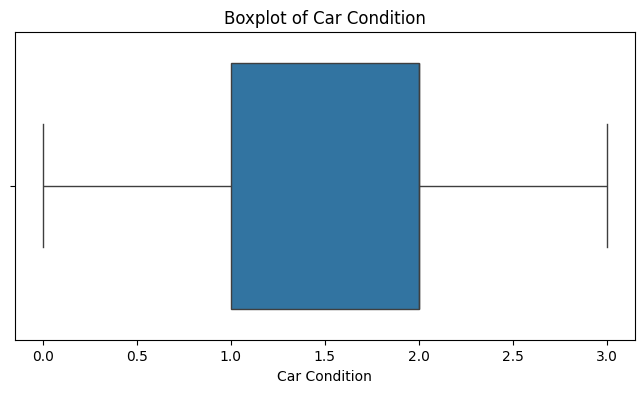

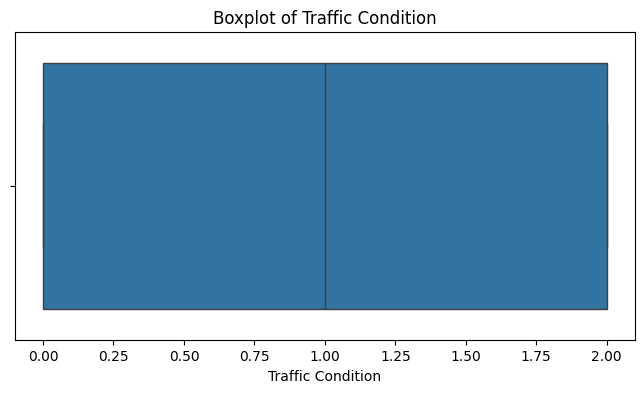

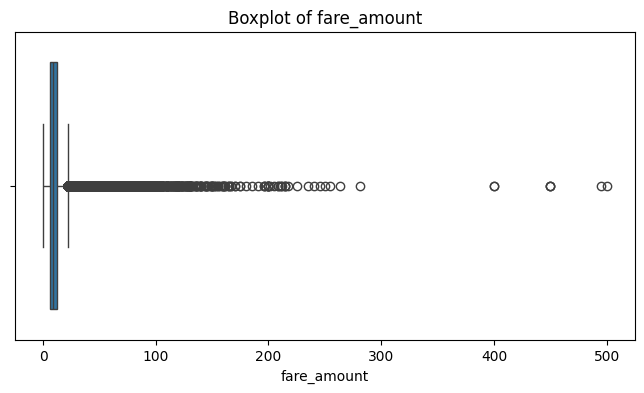

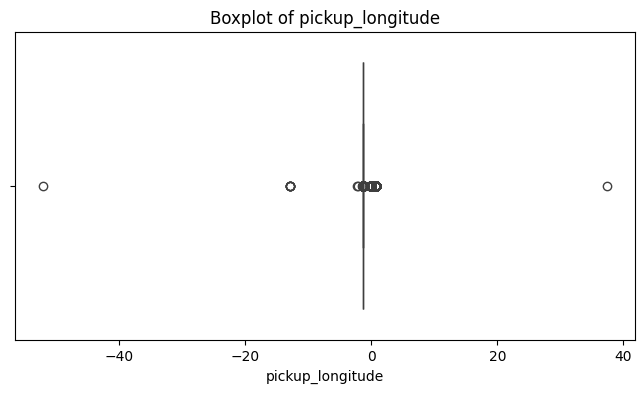

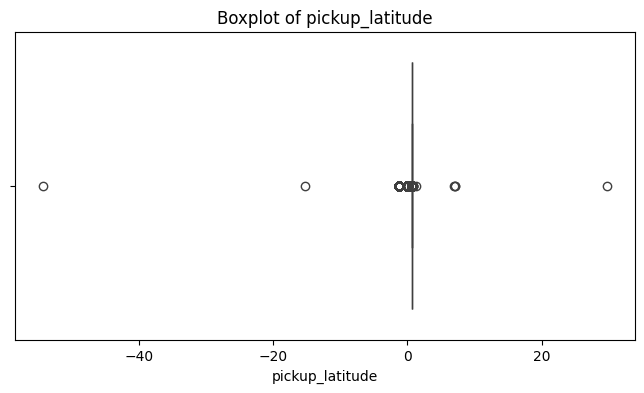

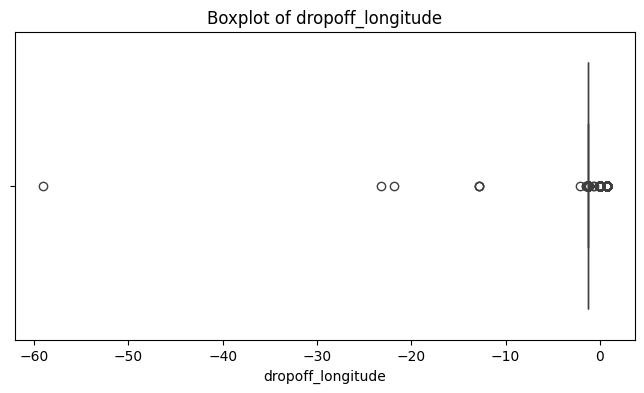

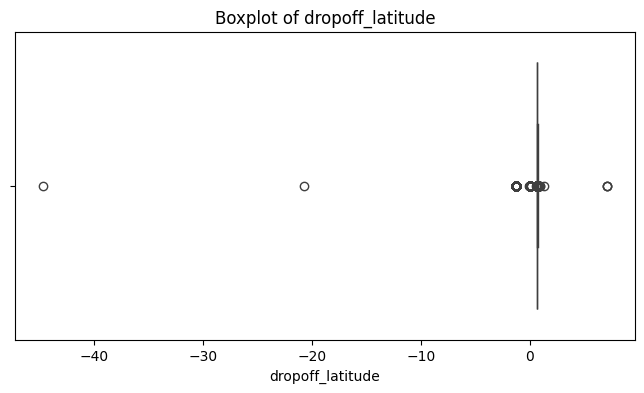

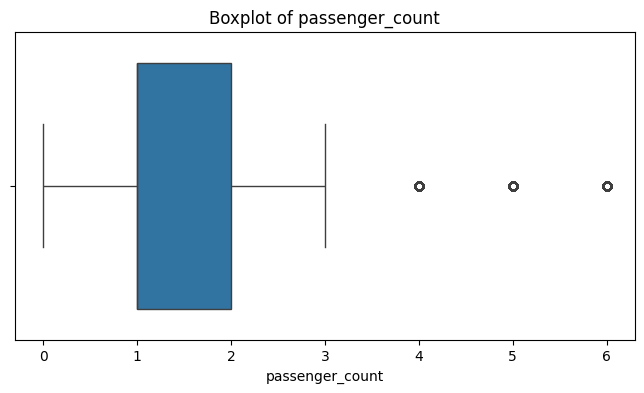

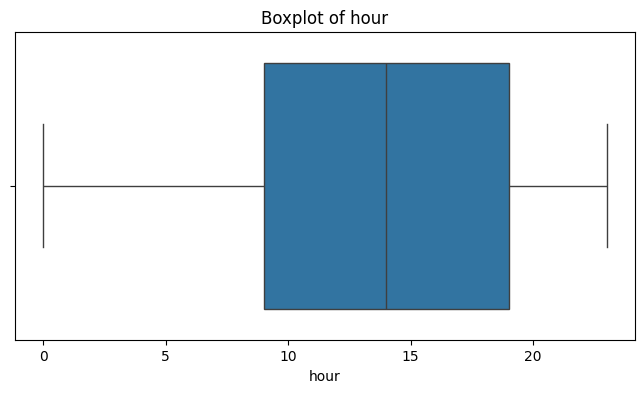

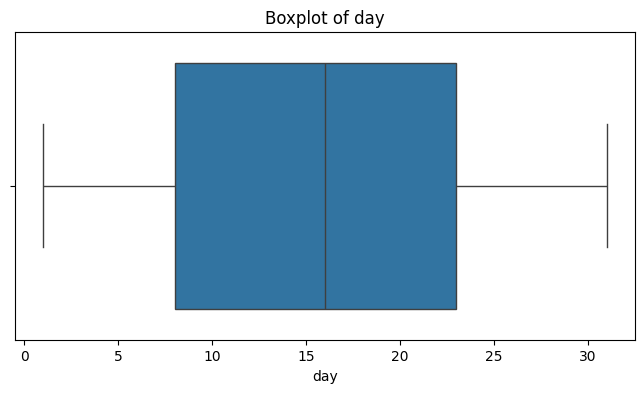

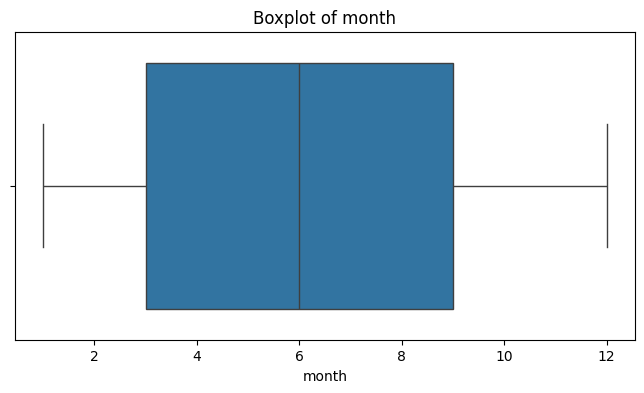

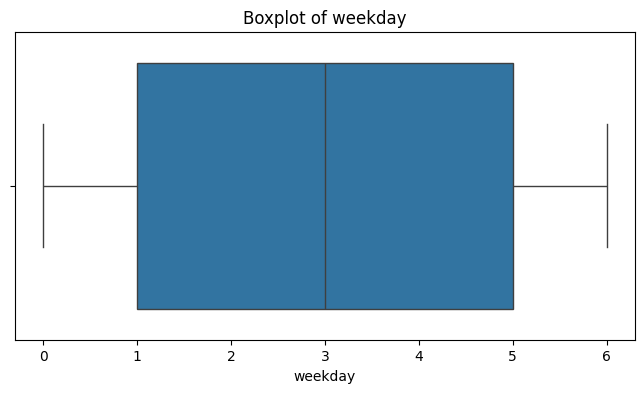

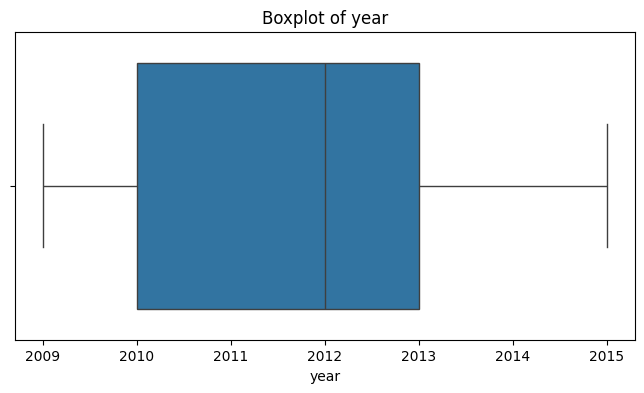

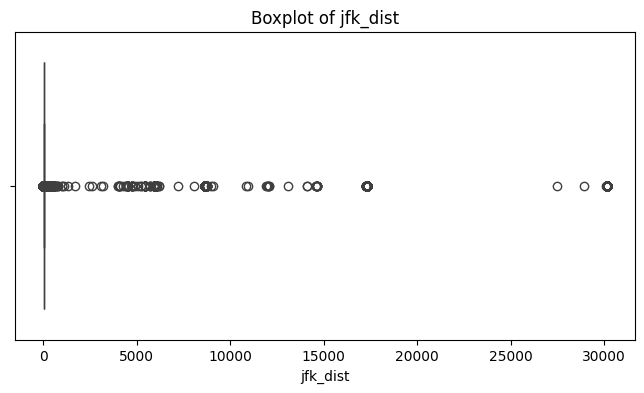

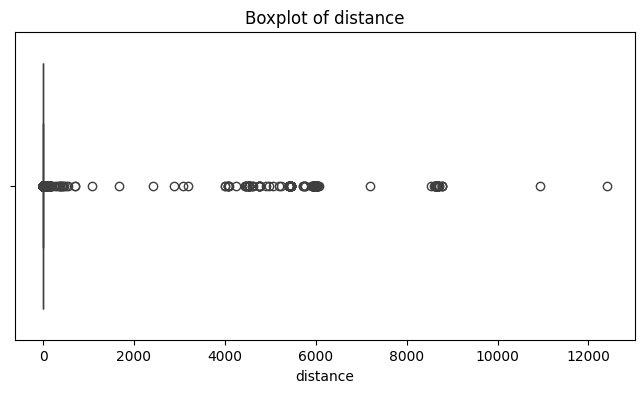

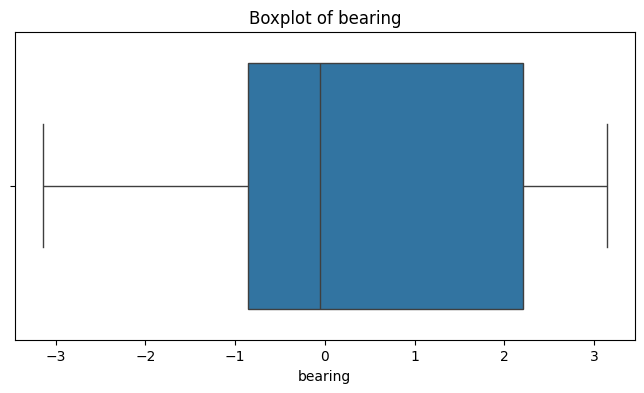

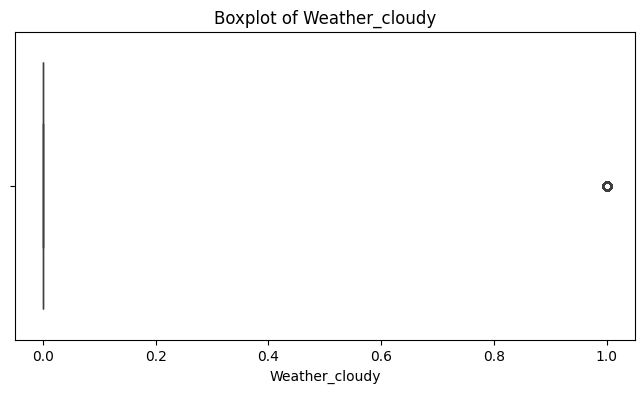

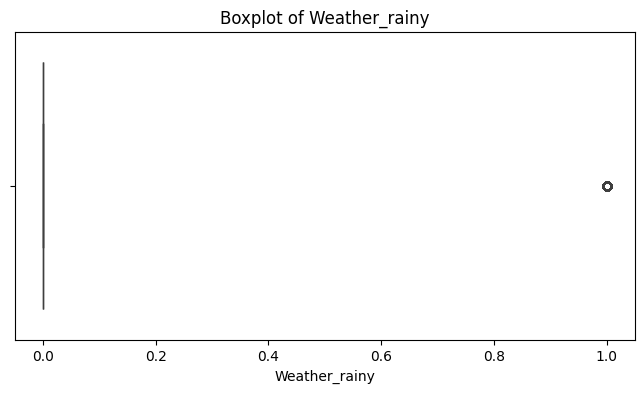

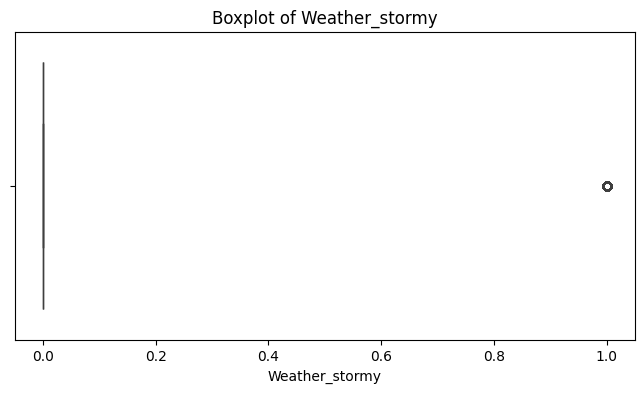

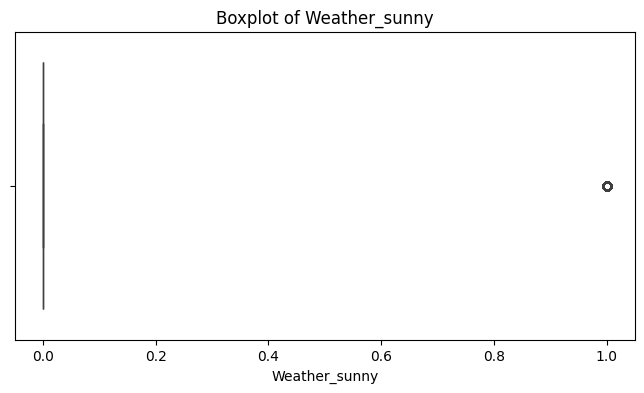

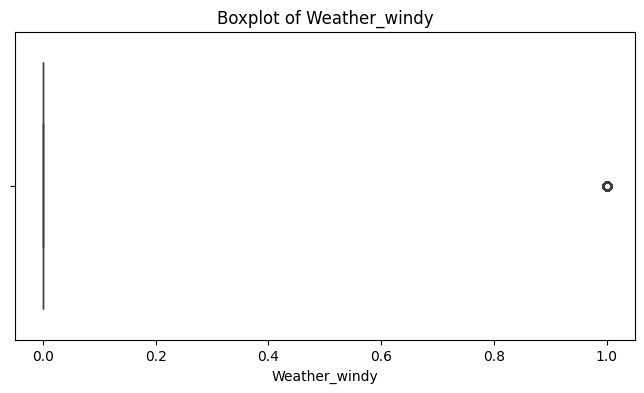

In [344]:
# box plot for see the outliers for each feature
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [345]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Car Condition,499974.0,1.499660,1.117530,0.000000,1.000000,2.000000,2.000000,3.000000
Traffic Condition,499974.0,1.000562,0.816596,0.000000,0.000000,1.000000,2.000000,2.000000
fare_amount,499974.0,11.358926,9.915433,0.000000,6.000000,8.500000,12.500000,500.000000
pickup_longitude,499974.0,-1.265713,0.206938,-52.119764,-1.291405,-1.291226,-1.290970,37.360538
pickup_latitude,499974.0,0.696741,0.140909,-54.389440,0.710958,0.711268,0.711520,29.724576
dropoff_longitude,499974.0,-1.265757,0.205899,-59.049665,-1.291393,-1.291197,-1.290908,0.712985
dropoff_latitude,499974.0,0.696676,0.128996,-44.676047,0.710943,0.711277,0.711538,7.061893
passenger_count,499974.0,1.683440,1.307383,0.000000,1.000000,1.000000,2.000000,6.000000
hour,499974.0,13.510997,6.511511,0.000000,9.000000,14.000000,19.000000,23.000000
day,499974.0,15.684142,8.681110,1.000000,8.000000,16.000000,23.000000,31.000000


In [346]:
#the outliers here is acceptable
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (
    (df[numeric_cols] < lower_bound) |
    (df[numeric_cols] > upper_bound)
)

outlier_counts = outliers.sum().sort_values(ascending=False)

print(outlier_counts)

Weather_sunny        100426
Weather_cloudy       100056
Weather_rainy         99969
Weather_stormy        99950
Weather_windy         99573
jfk_dist              59283
passenger_count       56523
fare_amount           43320
distance              41923
dropoff_longitude     35801
pickup_longitude      33960
dropoff_latitude      30748
pickup_latitude       23700
Traffic Condition         0
Car Condition             0
year                      0
day                       0
hour                      0
weekday                   0
month                     0
bearing                   0
dtype: int64


In [347]:
# this is for see if there is a unexpected values for distance and fare amount
df[['pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude',
    'distance', 'jfk_dist', 'fare_amount']].sort_values(
    'distance', ascending=False
).head(20)

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,distance,jfk_dist,fare_amount
436233,-52.119764,-15.369848,-59.049665,-44.676047,12399.956433,27503.603940,4.10
269695,-1.291501,0.710715,-23.206270,0.711636,10942.515639,10973.116470,17.70
401445,0.000000,0.000000,-1.316561,0.711257,8786.235625,8786.781728,14.50
207647,0.000000,0.000000,-1.316393,0.711638,8785.843243,8786.190287,38.90
336392,0.000000,0.000000,-1.314138,0.710343,8773.725816,8774.745070,34.50
419362,0.000000,0.000000,-1.303583,0.701458,8713.610002,8738.622608,5.70
388089,-1.301879,0.703394,0.000000,0.000000,8707.602344,8725.144579,13.70
309126,-1.298575,0.710328,0.000000,0.000000,8699.681549,8699.775485,120.75
212808,-1.296605,0.711809,0.000000,0.000000,8692.025319,8692.697447,135.50
394899,-1.295907,0.711441,0.000000,0.000000,8688.290444,8688.740876,12.00


In [348]:
df[['distance', 'fare_amount']].describe()

,distance,fare_amount
count,499974.000000,499974.000000
mean,19.452227,11.358926
std,367.104560,9.915433
min,0.000000,0.000000
25%,1.214637,6.000000
50%,2.116997,8.500000
75%,3.890147,12.500000
max,12399.956433,500.000000


In [285]:
# انا مش فاهمة هب ده منطقي يعني
df[df['fare_amount'] == 500][['distance', 'fare_amount']]

,distance,fare_amount
101885,0.0,500.0


In [349]:

df.loc[101885, [
    'pickup_longitude',
    'pickup_latitude',
    'dropoff_longitude',
    'dropoff_latitude',
    'distance',
    'fare_amount'
]]

,101885
pickup_longitude,-1.290950
pickup_latitude,0.709312
dropoff_longitude,-1.290950
dropoff_latitude,0.709312
distance,0.000000
fare_amount,500.000000


In [381]:
X = df.drop(columns=['fare_amount'])
y = df['fare_amount']

In [382]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [383]:
X_train_sample = X_train.sample(
    n=100000,
    random_state=42
)

y_train_sample = y_train.loc[X_train_sample.index]

In [384]:
baseline_pipeline = Pipeline(
    steps=[
        ('model', LinearRegression())
    ]
)

In [385]:
baseline_pipeline.fit(
    X_train_sample,
    y_train_sample
)

Pipeline(steps=[('model', LinearRegression())])

In [386]:
pred_lr = baseline_pipeline.predict(X_test)

mae_lr = mean_absolute_error(
    y_test,
    pred_lr
)

rmse_lr = np.sqrt(
    mean_squared_error(y_test, pred_lr)
)

r2_lr = r2_score(
    y_test,
    pred_lr
)

print("Linear Regression")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2:", r2_lr)

Linear Regression
MAE: 5.991202444770294
RMSE: 9.805397435037325
R2: 0.01538996286437977


In [387]:
cv = KFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

In [388]:
cv_results_lr = cross_validate(
    baseline_pipeline,
    X_train_sample,
    y_train_sample,
    cv=cv,
    scoring={
        'MAE': 'neg_mean_absolute_error',
        'RMSE': 'neg_root_mean_squared_error',
        'R2': 'r2'
    },
    n_jobs=-1
)

In [389]:
print(
    "CV MAE:",
    -cv_results_lr['test_MAE'].mean()
)

print(
    "CV RMSE:",
    -cv_results_lr['test_RMSE'].mean()
)

print(
    "CV R2:",
    cv_results_lr['test_R2'].mean()
)

CV MAE: 5.943016048987833
CV RMSE: 9.746203968263996
CV R2: 0.015709599953248832


In [390]:
from sklearn.ensemble import HistGradientBoostingRegressor
hgb_pipeline = Pipeline(
    steps=[
        (
            'model',
            HistGradientBoostingRegressor(
                max_iter=300,
                learning_rate=0.08,
                max_leaf_nodes=31,
                max_depth=None,
                min_samples_leaf=20,
                l2_regularization=1.0,
                early_stopping=True,
                random_state=42
            )
        )
    ]
)

In [391]:
#HistGradientBoostingRegressor
cv_results_hgb = cross_validate(
    hgb_pipeline,
    X_train_sample,
    y_train_sample,
    cv=cv,
    scoring={
        'MAE': 'neg_mean_absolute_error',
        'RMSE': 'neg_root_mean_squared_error',
        'R2': 'r2'
    },
    n_jobs=-1
)


In [392]:
print("MAE:", -cv_results_hgb['test_MAE'].mean())
print("RMSE:", -cv_results_hgb['test_RMSE'].mean())
print("R2:", cv_results_hgb['test_R2'].mean())

MAE: 1.9429227809285152
RMSE: 4.640972299717915
R2: 0.7767157447172002


In [393]:
from xgboost import XGBRegressor
xgb_pipeline = Pipeline(
    steps=[
        (
            'model',
            XGBRegressor(
                n_estimators=500,
                learning_rate=0.05,
                max_depth=8,
                min_child_weight=3,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_alpha=0.1,
                reg_lambda=1.0,
                objective='reg:squarederror',
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


In [394]:
cv_results_xgb = cross_validate(
    xgb_pipeline,
    X_train_sample,
    y_train_sample,
    cv=cv,
    scoring={
        'MAE': 'neg_mean_absolute_error',
        'RMSE': 'neg_root_mean_squared_error',
        'R2': 'r2'
    },
    n_jobs=-1
)

In [395]:
print("MAE:", -cv_results_xgb['test_MAE'].mean())
print("RMSE:", -cv_results_xgb['test_RMSE'].mean())
print("R2:", cv_results_xgb['test_R2'].mean())

MAE: 1.8287354456486475
RMSE: 4.562632626945343
R2: 0.7841224931648134


In [396]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'HistGradientBoosting',
        'XGBoost'
    ],

    'CV_MAE': [
        -cv_results_lr['test_MAE'].mean(),
        -cv_results_hgb['test_MAE'].mean(),
        -cv_results_xgb['test_MAE'].mean()
    ],

    'CV_RMSE': [
        -cv_results_lr['test_RMSE'].mean(),
        -cv_results_hgb['test_RMSE'].mean(),
        -cv_results_xgb['test_RMSE'].mean()
    ],

    'CV_R2': [
        cv_results_lr['test_R2'].mean(),
        cv_results_hgb['test_R2'].mean(),
        cv_results_xgb['test_R2'].mean()
    ]
})

results.sort_values(
    by='CV_RMSE',
    ascending=True
)

,Model,CV_MAE,CV_RMSE,CV_R2
2,XGBoost,1.828735,4.562633,0.784122
1,HistGradientBoosting,1.942923,4.640972,0.776716
0,Linear Regression,5.943016,9.746204,0.015710


In [397]:
best_model = results.loc[
    results['CV_RMSE'].idxmin()
]

print("Best Model:")
print(best_model)

Best Model:
Model       XGBoost
CV_MAE     1.828735
CV_RMSE    4.562633
CV_R2      0.784122
Name: 2, dtype: object


In [398]:
param_dist_xgb = {
    'model__n_estimators': [200, 300, 500, 700],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.08, 0.1],
    'model__max_depth': [3, 5, 6, 8, 10],
    'model__min_child_weight': [1, 3, 5, 7],
    'model__subsample': [0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'model__reg_alpha': [0, 0.01, 0.1, 1],
    'model__reg_lambda': [1, 2, 5, 10]
}

In [399]:
from sklearn.model_selection import RandomizedSearchCV

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_dist_xgb,
    n_iter=10,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [400]:
random_search_xgb.fit(
    X_train_sample,
    y_train_sample
)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=KFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('model',
                                              XGBRegressor(base_score=None,
                                                           booster=None,
                                                           callbacks=None,
                                                           colsample_bylevel=None,
                                                           colsample_bynode=None,
                                                           colsample_bytree=0.8,
                                                           device=None,
                                                           early_stopping_rounds=None,
                                                           enable_categorical=True,
                                                           eval_metric=None,
                                                           feature_types=None,
                                                           feature_weights=None,
                                                           gam...
                   param_distributions={'model__colsample_bytree': [0.7, 0.8,
                                                                    0.9, 1.0],
                                        'model__learning_rate': [0.01, 0.03,
                                                                 0.05, 0.08,
                                                                 0.1],
                                        'model__max_depth': [3, 5, 6, 8, 10],
                                        'model__min_child_weight': [1, 3, 5, 7],
                                        'model__n_estimators': [200, 300, 500,
                                                                700],
                                        'model__reg_alpha': [0, 0.01, 0.1, 1],
                                        'model__reg_lambda': [1, 2, 5, 10],
                                        'model__subsample': [0.7, 0.8, 0.9,
                                                             1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

In [401]:
print("Best Parameters:")
print(random_search_xgb.best_params_)

Best Parameters:
{'model__subsample': 0.9, 'model__reg_lambda': 5, 'model__reg_alpha': 0, 'model__n_estimators': 300, 'model__min_child_weight': 3, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.8}


In [402]:
best_cv_rmse = -random_search_xgb.best_score_

print("Best CV RMSE:", best_cv_rmse)

Best CV RMSE: 4.5579845459372486


In [403]:
scoring='neg_root_mean_squared_error'

In [404]:
best_xgb_model = random_search_xgb.best_estimator_

In [405]:
best_xgb_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=0.8, device=None,
                              early_stopping_rounds=None,
                              enable_categorical=True, eval_metric=None,
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=5, max_leaves=None, min_child_weight=3,
                              missing=nan, monotone_constraints=None,
                              multi_strategy=None, n_estimators=300, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [406]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

final_predictions = best_xgb_model.predict(X_test)

final_mae = mean_absolute_error(
    y_test,
    final_predictions
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_predictions
    )
)

final_r2 = r2_score(
    y_test,
    final_predictions
)

print("Final Model Results")
print("-------------------")
print("MAE:", final_mae)
print("RMSE:", final_rmse)
print("R2:", final_r2)

Final Model Results
-------------------
MAE: 1.8353416994057439
RMSE: 4.379727407796732
R2: 0.803560862699724


In [412]:
best_xgb_model = random_search_xgb.best_estimator_

cv_results_xgb_tuned = cross_validate(
    best_xgb_model,
    X_train_sample,
    y_train_sample,
    cv=cv,
    scoring={
        'MAE': 'neg_mean_absolute_error',
        'RMSE': 'neg_root_mean_squared_error',
        'R2': 'r2'
    },
    n_jobs=-1
)

In [414]:
comparison = pd.DataFrame({
    'Model': [
        'XGBoost Before Tuning',
        'XGBoost After Tuning'
    ],

    'CV_MAE': [
        -cv_results_xgb['test_MAE'].mean(),
        -cv_results_xgb_tuned['test_MAE'].mean()
    ],

    'CV_RMSE': [
        -cv_results_xgb['test_RMSE'].mean(),
        -cv_results_xgb_tuned['test_RMSE'].mean()
    ],

    'CV_R2': [
        cv_results_xgb['test_R2'].mean(),
        cv_results_xgb_tuned['test_R2'].mean()
    ]
})

comparison.round(6)

,Model,CV_MAE,CV_RMSE,CV_R2
0,XGBoost Before Tuning,1.828735,4.562633,0.784122
1,XGBoost After Tuning,1.887061,4.557985,0.784584
